# Кластерный анализ ：Flame синтетических данных（KMeans + Silhouette）

**Цель ：**  
1) Загрузить данные `flame.txt` (x1, x2, class)  
2) Выполнить KMeans кластеризацию (k=2)  
3) Визуализировать результат (цветные кластеры + центроиды)  
4) Провести силуэтный анализ (индекс силуэта, silhouette plot)  



In [3]:
# === Шаг 0. Импорт библиотек и настройки ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# Использование стандартных настроек для корректного отображения
plt.rcParams['axes.unicode_minus'] = False
print("Libraries loaded successfully")


Libraries loaded successfully


In [ ]:
# === Шаг 1. Загрузка данных ===
filename = 'flame.txt'
df_raw = pd.read_csv(filename, sep=r'\s+', header=None) 
print("--- Первые 5 строк исходных данных ---")
print(df_raw.head(5)) 


--- Первые 5 строк исходных данных ---
      0      1      2
0    x1     x2  class
1  1.85   27.8      1
2  1.35  26.65      1
3   1.4  23.25      2
4  0.85  23.05      2


Загружено 240 строк. Теперь данные чистые и готовы к работе.


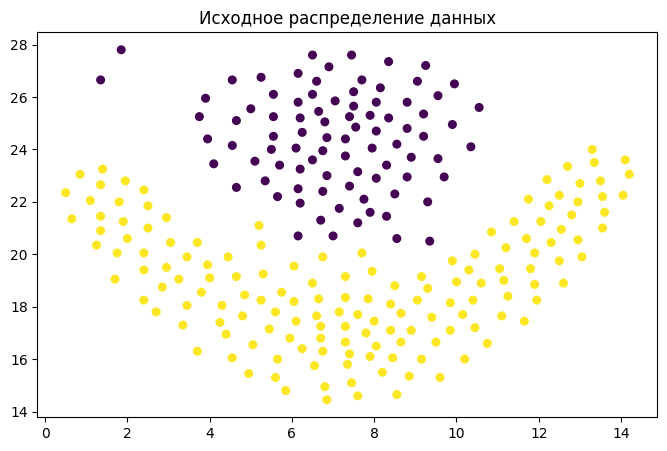

In [ ]:
# === Шаг 2. Определение структуры данных (на основе Шага 1) ===
df = pd.read_csv('flame.txt', sep=r'\s+', header=0)
X = df[['x1', 'x2']].values.astype(float)
y_true = df['class'].values.astype(int)

print(f"Загружено {len(X)} строк. Теперь данные чистые и готовы к работе.")
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=30)
plt.title("Исходное распределение данных")
plt.show()

In [27]:
# === Шаг 3. Стандартизация и кластеризация k-means ===
# Для flame.txt обычно используется k=2
k = 2
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
print(f"Шаг 4: KMeans clustering completed for k={k}")


Шаг 4: KMeans clustering completed for k=2


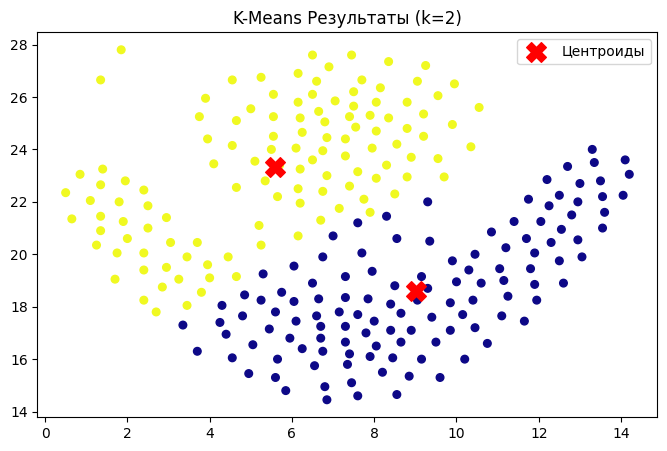

In [28]:
# === Шаг 4. Визуализация результатов кластеризации ===
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma', s=30)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Центроиды')
plt.title(f"K-Means Результаты (k={k})")
plt.legend()
plt.show()

In [29]:
# === Шаг 5. Расчет индекса силуэта ===
# Оценка качества кластеризации
avg_silhouette = silhouette_score(X_scaled, labels)
print(f"Средний коэффициент силуэта: {avg_silhouette:.4f}")


Средний коэффициент силуэта: 0.3733


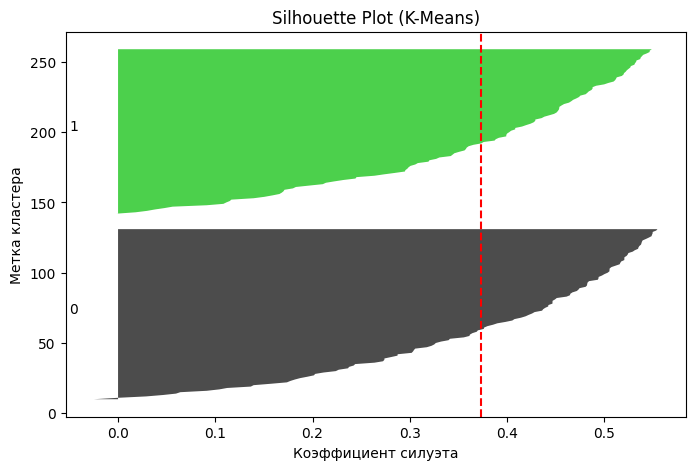

In [30]:
# === Шаг 6. Построение кластерных силуэтов ===
sample_values = silhouette_samples(X_scaled, labels)
fig, ax1 = plt.subplots(figsize=(8, 5))
y_lower = 10

for i in range(k):
    ith_cluster_values = sample_values[labels == i]
    ith_cluster_values.sort()
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.nipy_spectral(float(i) / k)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values, facecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax1.set_title("Silhouette Plot (K-Means)")
ax1.set_xlabel("Коэффициент силуэта")
ax1.set_ylabel("Метка кластера")
ax1.axvline(x=avg_silhouette, color="red", linestyle="--")
plt.show()

--- ОКОНЧАТЕЛЬНЫЙ АНАЛИЗ ЗАДАЧИ ---
1. Справился ли k-means с набором данных? Частично.
2. Почему? Набор данных о пламени содержит неконвексный (изогнутый) кластер.
3. Конкретные ограничения k-means, которые были замечены:
 - Сферическое предположение: k-means ожидает, что кластеры будут круглыми.
 - Линейная граница: он использует прямые линии для разделения кластеров, что разрезает кривые.
 - Евклидово расстояние: оно игнорирует форму и плотность траектории данных.